# P(k) absolute relative error vs k (k < 10)

Plots the three SZ3-based reconstructions produced by the real pipeline
(`SPERR/SPERR.py --task nyx_b --cr_target 500 --save_recons`) against the
original, using gimlet2's `sim_stats.ex` output in `ps3d_out/`. All
methods sit at a binary-searched effective CR ~= 500. The three SPERR
variants are computed too -- add their tags to `PLOT_TAGS` to draw them.

Each `*_rhob_ps3d.txt` has 4 columns: `[1] nominal k`, `[2] mode count`,
`[3] k` (power-weighted mean k for the bin), `[4] P(k)`.

Absolute relative error per bin: `abs((P(k)_method - P(k)_ori) / P(k)_ori)`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

OUT_DIR = "ps3d_out"
K_MAX = 10.0

STYLE = {
    "sz3":          dict(color="tab:gray",   marker="^", ls="--", label="SZ3"),
    "sz3_ours":     dict(color="tab:blue",   marker="o", ls="-",  label="SZ3+Ours"),
    "sz3_neurlz":   dict(color="tab:red",    marker="v", ls=":",  label="SZ3+NeurLZ"),
    "sperr":        dict(color="tab:green",  marker="s", ls="--", label="SPERR"),
    "sperr_ours":   dict(color="tab:purple", marker="P", ls="-",  label="SPERR+Ours"),
    "sperr_neurlz": dict(color="tab:brown",  marker="X", ls=":",  label="SPERR+NeurLZ"),
}

# Which series to draw. compare_pk.py computes all six; the SPERR family is
# kept out of the figure (their numbers stay in the paper's table).
PLOT_TAGS = ["sz3", "sz3_ours", "sz3_neurlz"]

ori = np.loadtxt(f"{OUT_DIR}/ori_rhob_ps3d.txt")
k = ori[:, 2]      # column 3: k
po = ori[:, 3]     # column 4: P(k)
mask = k < K_MAX

rel_err = {}
for tag in PLOT_TAGS:
    d = np.loadtxt(f"{OUT_DIR}/{tag}_rhob_ps3d.txt")
    assert np.array_equal(ori[:, 1], d[:, 1]), f"{tag}: bins not aligned with ori"
    rel_err[tag] = np.abs((d[:, 3] - po) / po)

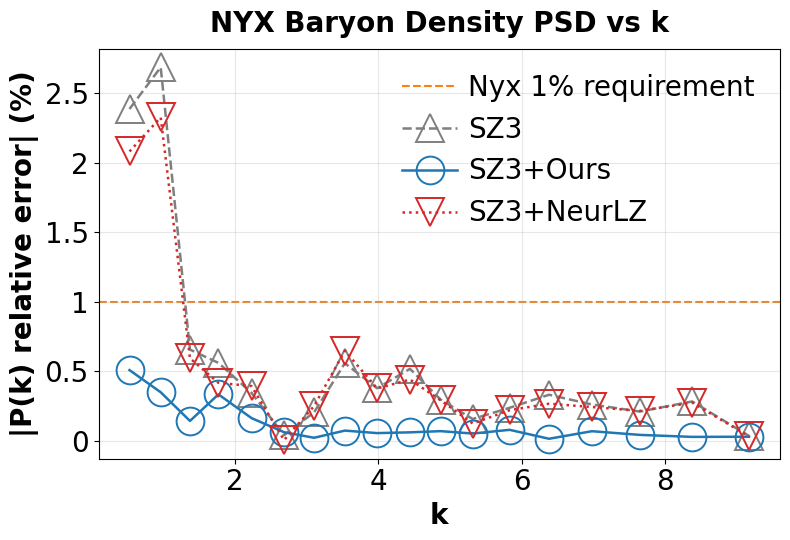

In [5]:
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(8, 5.5))

ax.axhline(1.0, color="tab:orange", ls="--", lw=1.5, zorder=1,
           label="Nyx 1% requirement")
for tag in PLOT_TAGS:
    sty = STYLE[tag]
    ax.plot(k[mask], rel_err[tag][mask] * 100,
            color=sty["color"], marker=sty["marker"], ls=sty["ls"], lw=1.8,
            markerfacecolor="none", markeredgecolor=sty["color"], markeredgewidth=1.4,
            markersize=20, label=sty["label"], zorder=3)

FONTSIZE = 20

# ax.set_xscale("log")
# ax.set_yscale("log")

# 设置 X 轴和 Y 轴 Label 为粗体 (fontweight="bold")
ax.set_xlabel("k", fontsize=FONTSIZE, fontweight="bold")
ax.set_ylabel("|P(k) relative error| (%)", fontsize=FONTSIZE, fontweight="bold")

# plain decimals (0.01/0.1/1/10) rather than 10^-2 style
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
ax.tick_params(axis="both", which="major", labelsize=FONTSIZE)

ax.grid(True, which="major", alpha=0.3)
ax.grid(True, which="minor", alpha=0.12)


ax.set_title("NYX Baryon Density PSD vs k", fontsize=FONTSIZE, pad=12, fontweight="bold")


leg = ax.legend(loc="upper right", fontsize=20, frameon=False, handletextpad=0.4)

plt.tight_layout()
plt.savefig("pk_relerr_cr500_k_lt_10.pdf", dpi=150, bbox_inches="tight")
plt.show()
